In [13]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [14]:
stocks = [
    "ADANIENT.NS",
    "ADANIPORTS.NS",
    "APOLLOHOSP.NS",
    "ASIANPAINT.NS",
    "AXISBANK.NS",
    "BAJAJ-AUTO.NS",
    "BAJFINANCE.NS",
    "BEL.NS",
    "BHARTIARTL.NS",
    "CIPLA.NS",
    "COALINDIA.NS",
    "DRREDDY.NS",
    "EICHERMOT.NS",
    "ETERNAL.NS",   # formerly Zomato
    "GRASIM.NS",
    "HCLTECH.NS",
    "HDFCBANK.NS",
    "HDFCLIFE.NS",
    "HEROMOTOCO.NS",
    "HINDALCO.NS",
    "HINDUNILVR.NS",
    "ICICIBANK.NS",
    "INDUSINDBK.NS",
    "INFY.NS",
    "ITC.NS",
    "JIOFIN.NS",
    "JSWSTEEL.NS",
    "KOTAKBANK.NS",
    "LT.NS",
    "M&M.NS",
    "MARUTI.NS",
    "NESTLEIND.NS",
    "NTPC.NS",
    "ONGC.NS",
    "POWERGRID.NS",
    "RELIANCE.NS",
    "SBILIFE.NS",
    "SBIN.NS",
    "SHRIRAMFIN.NS",
    "SUNPHARMA.NS",
    "TATACONSUM.NS",
    "TATAMOTORS.NS",
    "TATASTEEL.NS",
    "TCS.NS",
    "TECHM.NS",
    "TITAN.NS",
    "TRENT.NS",
    "ULTRACEMCO.NS",
    "WIPRO.NS"
]


start = "2020-01-01"

In [15]:
data = yf.download(
    stocks,
    start="2020-01-01",
    auto_adjust=True,
    progress=False
)

close=data["Close"]
volume=data["Volume"]



HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


In [16]:
sma20 = close.rolling(20).mean()

std20 =close.rolling(20).std()

upper_band = sma20 + 2 * std20
lower_band = sma20 - 2 * std20

bb_width = (upper_band - lower_band) / sma20

In [17]:
compression = (
    bb_width
    <=
    bb_width.rolling(60).quantile(0.10)
)

high20 = close.shift(1).rolling(20).max()

breakout = close > high20

avg_volume = volume.shift(1).rolling(20).mean()

volume_signal = volume > 1.5 * avg_volume


In [18]:
entry_signal = (
    compression
    &
    breakout
    &
    volume_signal
)

ema20 = close.ewm(span=20).mean()

exit_signal = close < ema20

In [19]:
positions = pd.DataFrame(
    0,
    index=close.index,
    columns=close.columns
)


for stock in close.columns:

    in_position = False

    for i in range(1, len(close)):

        date = close.index[i]

        if not in_position:

            if entry_signal.loc[date, stock]:

                positions.loc[date, stock] = 1

                in_position = True

        else:

            positions.loc[date, stock] = 1

            if exit_signal.loc[date, stock]:

                in_position = False


                

In [20]:
positions = positions.shift(1).fillna(0)

returns = close.pct_change()

strategy_returns = (
    (positions * returns).sum(axis=1)
    /
    positions.sum(axis=1).replace(0, np.nan)
)

strategy_returns = strategy_returns.fillna(0)

equity_curve = (
    1 + strategy_returns
).cumprod()


benchmark_returns = returns.mean(axis=1)

benchmark_curve = (
    1 + benchmark_returns
).cumprod()

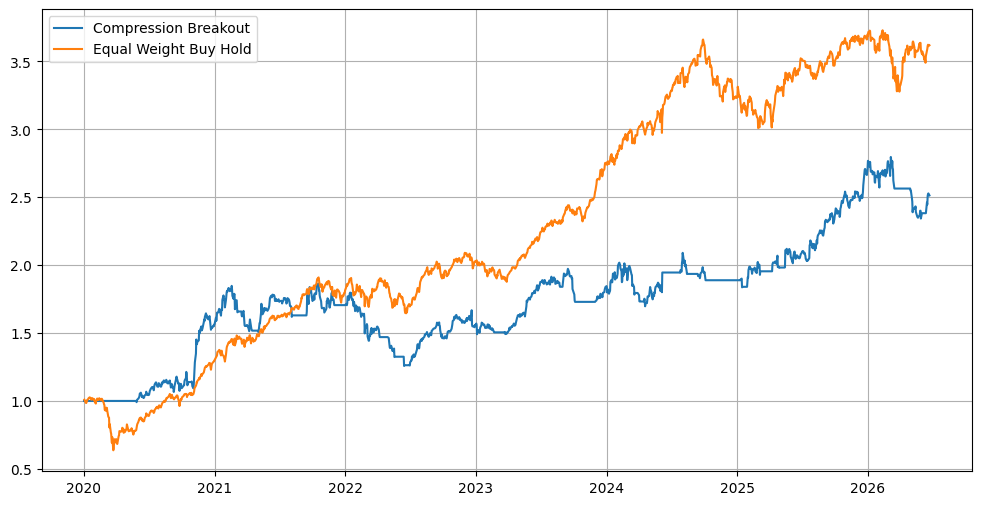

In [21]:
plt.figure(figsize=(12,6))

plt.plot(
    equity_curve,
    label="Compression Breakout"
)

plt.plot(
    benchmark_curve,
    label="Equal Weight Buy Hold"
)

plt.legend()

plt.grid()

plt.show()

In [22]:
years = (
    equity_curve.index[-1]
    -
    equity_curve.index[0]
).days / 365.25

cagr = (
    equity_curve.iloc[-1]
    **
    (1 / years)
    - 1
)

sharpe = (
    strategy_returns.mean()
    /
    strategy_returns.std()
) * np.sqrt(252)

running_max = equity_curve.cummax()

drawdown = (
    equity_curve
    /
    running_max
    -
    1
)

max_dd = drawdown.min()

print(
    "Benchmark Return:",
    round(
        (benchmark_curve.iloc[-1]-1)*100,
        2
    ),
    "%"
)

print(f"Strategy Return: {(equity_curve.iloc[-1]-1)*100:.2f}%")
print(f"CAGR: {cagr:.2%}")
print(f"Sharpe: {sharpe:.2f}")
print(f"Max Drawdown: {max_dd:.2%}")


Benchmark Return: 261.94 %
Strategy Return: 151.38%
CAGR: 15.31%
Sharpe: 0.83
Max Drawdown: -32.54%


In [23]:
active_positions = positions.sum(axis=1)

print(active_positions.describe())

print("Total Signals:",
      entry_signal.sum().sum())

count    1604.000000
mean        2.006858
std         2.408516
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        13.000000
dtype: float64
Total Signals: 230
